# Lagemaße: Mittelwert, Median und Modus

> Quelle: [numiqo.de](https://numiqo.de/tutorial/mittelwert-median-modus)  
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

**Lagemaße** geben Auskunft darüber, wo die „Mitte" einer Verteilung liegt – also was „normal" oder „üblich" in einer Datenmenge ist.

Die drei wichtigsten Lagemaße sind:

| Lagemaß | Beschreibung | Skalenniveau |
|---|---|---|
| **Mittelwert** | Summe aller Werte ÷ Anzahl | Metrisch |
| **Median** | Mittlerer Wert der sortierten Reihe | Ordinal oder metrisch |
| **Modus (Modalwert)** | Häufigster Wert | Nominal, ordinal oder metrisch |

> Zusammen mit den **Streuungsmaßen** beschreiben Lagemaße eine Verteilung vollständig.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Mittelwert (Arithmetisches Mittel)

Der **Mittelwert** (auch: arithmetisches Mittel, Durchschnitt) ist das bekannteste Lagemaß.  
Er wird berechnet, indem die **Summe aller Werte durch die Anzahl der Werte** geteilt wird.

### Formel

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

### Eigenschaften
- Nur für **metrische Variablen** sinnvoll
- **Sensitiv gegenüber Ausreißern** – ein extremer Wert verschiebt den Mittelwert stark
- Der berechnete Wert muss **nicht in den Daten vorkommen**

### Beispiel (numiqo)
5 Studierende trinken pro Woche: **21, 25, 10, 8, 11** Tassen Kaffee.

$$\bar{x} = \frac{21 + 25 + 10 + 8 + 11}{5} = \frac{75}{5} = 15$$

In [2]:
# Beispiel: Kaffeekonsum pro Woche
kaffee = pd.Series([21, 25, 10, 8, 11])

mittelwert = kaffee.mean()
print(f"Werte:      {list(kaffee)}")
print(f"Summe:      {kaffee.sum()}")
print(f"Anzahl (n): {len(kaffee)}")
print(f"Mittelwert: {kaffee.sum()} / {len(kaffee)} = {mittelwert}")

# Weitere Mittelwertarten
from scipy.stats import gmean
geo_mittel = gmean(kaffee)
quad_mittel = np.sqrt(np.mean(kaffee**2))

print(f"\nMittelwertarten im Vergleich")
print(f"Arithmetisches Mittel: {mittelwert:.4f}")
print(f"Geometrisches Mittel:  {geo_mittel:.4f}")
print(f"Quadratisches Mittel:  {quad_mittel:.4f}")

Werte:      [21, 25, 10, 8, 11]
Summe:      75
Anzahl (n): 5
Mittelwert: 75 / 5 = 15.0

Mittelwertarten im Vergleich
Arithmetisches Mittel: 15.0000
Geometrisches Mittel:  13.5809
Quadratisches Mittel:  16.4378


## 2. Median

Der **Median** ist der **mittlere Wert** einer sortierten Datenreihe.  
Er teilt die Verteilung in zwei gleich große Hälften: 50 % der Werte liegen darunter, 50 % darüber.

### Berechnung

- **Ungerade Anzahl** (n): Der Median ist der Wert an Position $\frac{n+1}{2}$
- **Gerade Anzahl** (n): Der Median ist der Durchschnitt der beiden mittleren Werte (Position $\frac{n}{2}$ und $\frac{n}{2}+1$)

### Eigenschaften
- Mindestens **ordinales Skalenniveau** erforderlich
- **Robust gegenüber Ausreißern** – ein extremer Wert hat kaum Einfluss
- Der Wert kommt (bei gerader Anzahl) nicht zwingend in den Daten vor

> Bei **schiefen Verteilungen** oder **Ausreißern** ist der Median oft aussagekräftiger als der Mittelwert.

In [10]:
# Median – ungerade Anzahl
ungerade = pd.Series([3, 7, 1, 9, 5])
sortiert_u = ungerade.sort_values().reset_index(drop=True)
print("Ungerade Anzahl (n=5)")
print(f"Unsortiert: {list(ungerade)}")
print(f"Sortiert:   {list(sortiert_u)}")
print(f"Position:   {(len(ungerade)+1)//2}. Wert")
print(f"Median:     {ungerade.median()}")

# Median – gerade Anzahl
gerade = pd.Series([3, 7, 1, 9, 5, 11])
sortiert_g = gerade.sort_values().reset_index(drop=True)
n = len(gerade)
pos1, pos2 = n//2 - 1, n//2
print(f"\nGerade Anzahl (n=6)")
print(f"Unsortiert: {list(gerade)}")
print(f"Sortiert:   {list(sortiert_g)}")
print(f"Mittlere Werte: {sortiert_g[pos1]} und {sortiert_g[pos2]}")
print(f"Median: ({sortiert_g[pos1]} + {sortiert_g[pos2]}) / 2 = {gerade.median()}")

Ungerade Anzahl (n=5)
Unsortiert: [3, 7, 1, 9, 5]
Sortiert:   [1, 3, 5, 7, 9]
Position:   3. Wert
Median:     5.0

Gerade Anzahl (n=6)
Unsortiert: [3, 7, 1, 9, 5, 11]
Sortiert:   [1, 3, 5, 7, 9, 11]
Mittlere Werte: 5 und 7
Median: (5 + 7) / 2 = 6.0


## 3. Modus (Modalwert)

Der **Modus** (oder **Modalwert**) ist der **häufigste Wert** in einer Datenmenge.  
Er entspricht dem höchsten Punkt der Häufigkeitsverteilung.

### Eigenschaften
- Für **alle Skalenniveaus** geeignet (nominal, ordinal, metrisch)
- Der Wert **kommt immer tatsächlich in den Daten vor**
- Es kann **mehrere Modi** geben:
  - **unimodal** – ein häufigster Wert
  - **bimodal** – zwei häufigste Werte
  - **multimodal** – mehr als zwei häufigste Werte
- Berücksichtigt **keine anderen Werte** als den häufigsten

### Beispiel (numiqo)
70 ManagerInnen in Berlin fahren: 20× Daimler, **25× BMW**, 10× VW, 15× Audi  
→ Modus = **BMW** (häufigste Kategorie)

Modus bei nominaler Variable (Automarke)
BMW        25
Daimler    20
Audi       15
VW         10

Modus: BMW

Bimodale Verteilung
Daten: [1, 2, 2, 3, 3, 4, 5]
Modi:  [2, 3]  → bimodal!


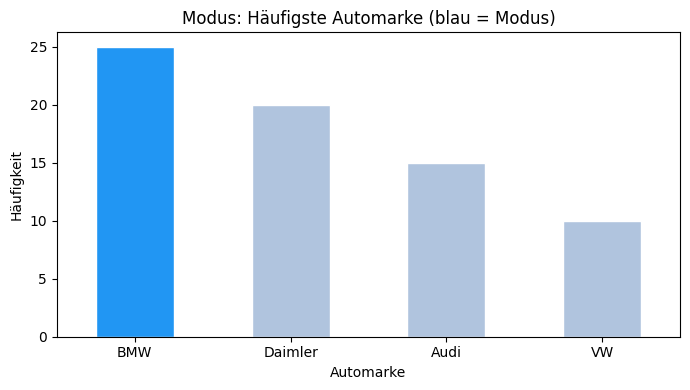

In [13]:
# Modus – kategorische Variable (nominal)
automarken = pd.Series(['Daimler']*20 + ['BMW']*25 + ['VW']*10 + ['Audi']*15)
haeuf = automarken.value_counts()
print("Modus bei nominaler Variable (Automarke)")
print(haeuf.to_string())
print(f"\nModus: {automarken.mode()[0]}")

# Modus – bimodale Verteilung
bimodal = pd.Series([1, 2, 2, 3, 3, 4, 5])
print(f"\nBimodale Verteilung")
print(f"Daten: {list(bimodal)}")
print(f"Modi:  {list(bimodal.mode())}  → bimodal!")

# Visualisierung Automarken
fig, ax = plt.subplots(figsize=(7, 4))
haeuf.sort_values(ascending=False).plot(
    kind='bar', ax=ax,
    color=['#2196F3' if x == automarken.mode()[0] else 'lightsteelblue' for x in haeuf.sort_values(ascending=False).index],
    edgecolor='white'
)
ax.set_title('Modus: Häufigste Automarke (blau = Modus)')
ax.set_xlabel('Automarke')
ax.set_ylabel('Häufigkeit')
ax.set_xticklabels(haeuf.sort_values(ascending=False).index, rotation=0)
plt.tight_layout()
plt.show()

## 4. Mittelwert vs. Median – Einfluss von Ausreißern

Der wichtigste praktische Unterschied zwischen Mittelwert und Median ist ihre **Robustheit gegenüber Ausreißern**:

- **Mittelwert**: sensitiv – ein einziger extremer Wert kann ihn stark verschieben
- **Median**: robust – Ausreißer haben kaum Einfluss

> **Beispiel:** Gehälter in einem Unternehmen – wenn der CEO ein sehr hohes Gehalt hat,  
> ist der **Median** als „typisches Gehalt" aussagekräftiger als der Mittelwert.

Ohne Ausreißer
Werte:      [2500, 2800, 3000, 3200, 2700, 2900, 3100, 2600]
Mittelwert: 2850 €
Median:     2850 €

Mit Ausreißer (CEO: 150.000 €)
Mittelwert: 19200 €  ← stark verschoben!
Median:     2900 €  ← kaum verändert


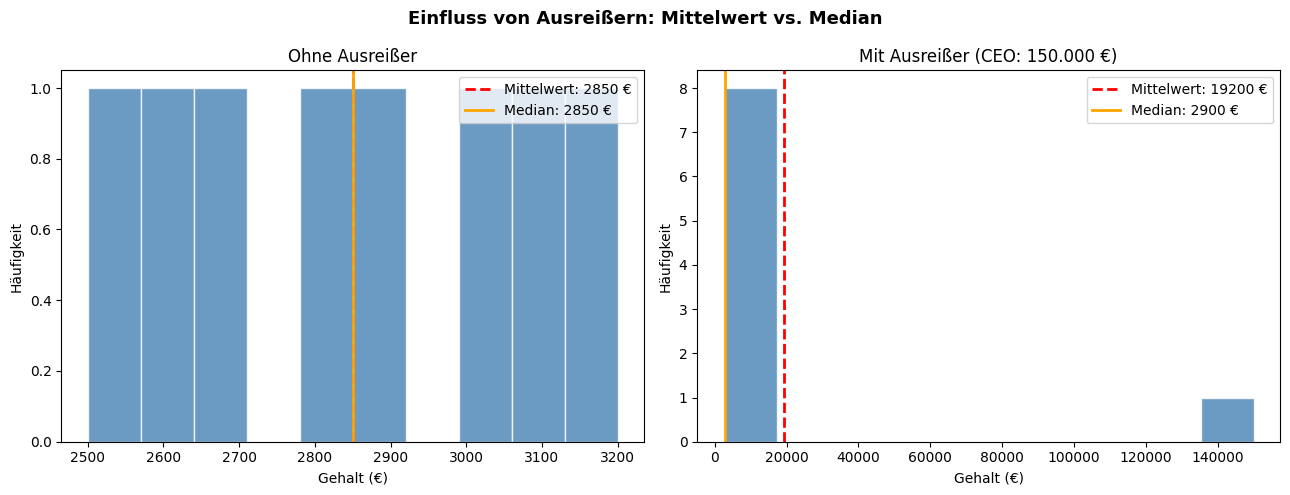

In [15]:
# Ausreißereffekt auf Mittelwert vs. Median
gehaelter_normal  = pd.Series([2500, 2800, 3000, 3200, 2700, 2900, 3100, 2600])
gehaelter_ausreißer = pd.concat([gehaelter_normal, pd.Series([150000])], ignore_index=True)

print("Ohne Ausreißer")
print(f"Werte:      {list(gehaelter_normal)}")
print(f"Mittelwert: {gehaelter_normal.mean():.0f} €")
print(f"Median:     {gehaelter_normal.median():.0f} €")

print("\nMit Ausreißer (CEO: 150.000 €)")
print(f"Mittelwert: {gehaelter_ausreißer.mean():.0f} €  ← stark verschoben!")
print(f"Median:     {gehaelter_ausreißer.median():.0f} €  ← kaum verändert")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, daten, titel in zip(
    axes,
    [gehaelter_normal, gehaelter_ausreißer],
    ['Ohne Ausreißer', 'Mit Ausreißer (CEO: 150.000 €)']
):
    ax.hist(daten, bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(daten.mean(),   color='red',    linestyle='--', linewidth=2,
               label=f'Mittelwert: {daten.mean():.0f} €')
    ax.axvline(daten.median(), color='orange', linestyle='-',  linewidth=2,
               label=f'Median: {daten.median():.0f} €')
    ax.set_title(titel)
    ax.set_xlabel('Gehalt (€)')
    ax.set_ylabel('Häufigkeit')
    ax.legend()

plt.suptitle('Einfluss von Ausreißern: Mittelwert vs. Median', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Vollständiges Beispiel: Statistik-Prüfung (aus numiqo)

Punktezahl von 10 Studierenden bei einer Statistik-Prüfung:

| Student | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| Punkte | 4 | 5 | 5 | 8 | 9 | 12 | 14 | 16 | 17 | 20 |

**Erwartete Ergebnisse laut numiqo:**

| Kennzahl | Wert |
|---|---|
| Mittelwert | 11 |
| Median | 10,5 |
| Modalwert | 5 |

Lagemaße: Statistik-Prüfung
Daten:      [4, 5, 5, 8, 9, 12, 14, 16, 17, 20]
Mittelwert: 11.0    (Summe 110 ÷ 10)
Median:     10.5  (Mittel aus 9 und 12)
Modus:      5    (kommt 2× vor)


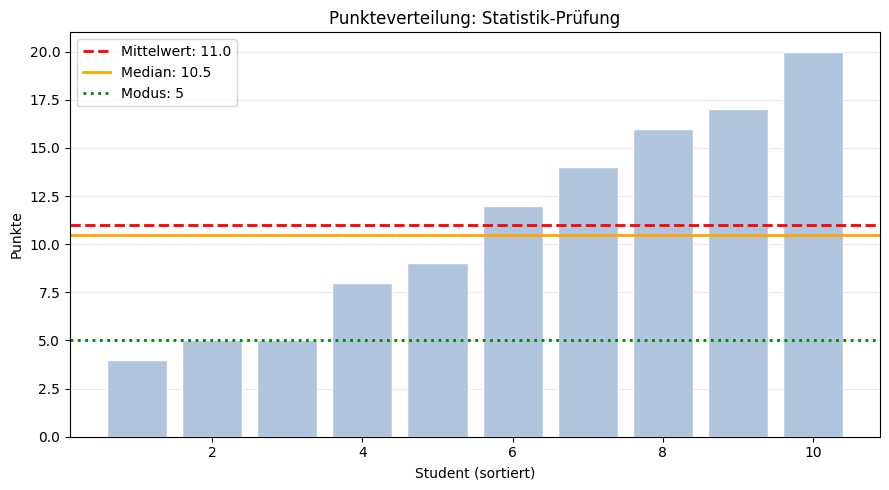

In [16]:
# numiqo Beispiel – Statistik-Prüfung
punkte = pd.Series([4, 5, 5, 8, 9, 12, 14, 16, 17, 20])

mw  = punkte.mean()
med = punkte.median()
mod = punkte.mode()[0]

print("Lagemaße: Statistik-Prüfung")
print(f"Daten:      {list(punkte)}")
print(f"Mittelwert: {mw}    (Summe {punkte.sum()} ÷ {len(punkte)})")
print(f"Median:     {med}  (Mittel aus {sorted(punkte)[4]} und {sorted(punkte)[5]})")
print(f"Modus:      {mod}    (kommt {(punkte == mod).sum()}× vor)")

# Visualisierung
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, len(punkte)+1), sorted(punkte),
       color='lightsteelblue', edgecolor='white', zorder=2)
ax.axhline(mw,  color='red',    linestyle='--', linewidth=2, label=f'Mittelwert: {mw}')
ax.axhline(med, color='orange', linestyle='-',  linewidth=2, label=f'Median: {med}')
ax.axhline(mod, color='green',  linestyle=':',  linewidth=2, label=f'Modus: {mod}')
ax.set_title('Punkteverteilung: Statistik-Prüfung')
ax.set_xlabel('Student (sortiert)')
ax.set_ylabel('Punkte')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()

## 6. Lage der Maße bei verschiedenen Verteilungsformen

Die relative Lage von Mittelwert, Median und Modus hängt von der **Form der Verteilung** ab:

| Verteilung | Beziehung |
|---|---|
| **Symmetrisch (Normalverteilung)** | Mittelwert ≈ Median ≈ Modus |
| **Rechtsschiefe (positiv schief)** | Modus < Median < Mittelwert |
| **Linksschiefe (negativ schief)** | Mittelwert < Median < Modus |

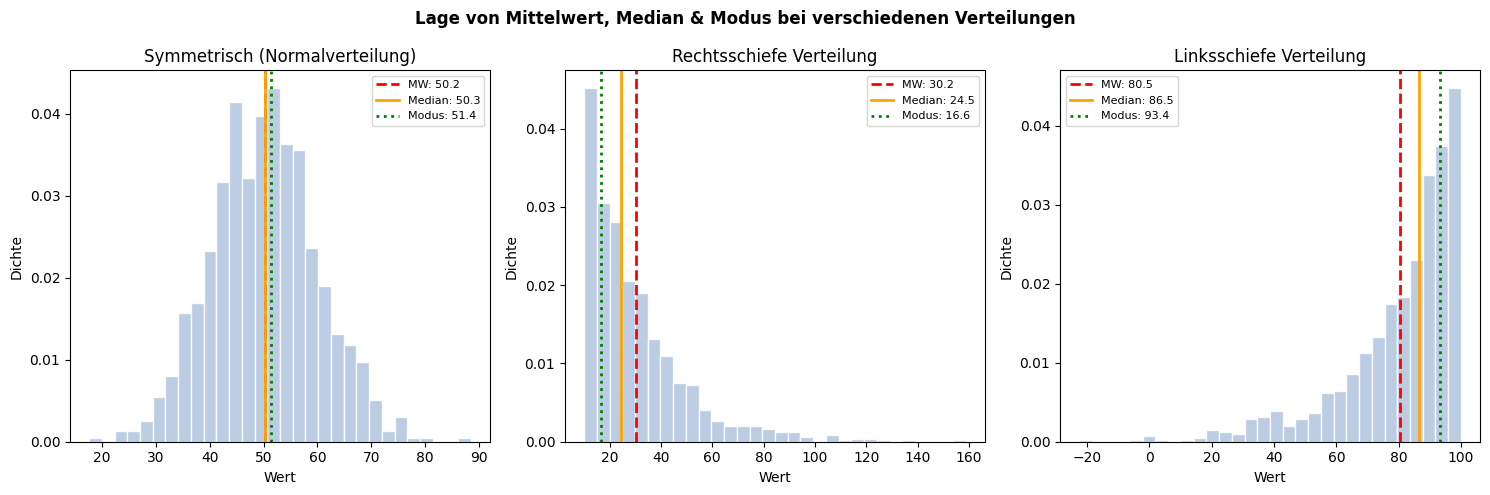

In [7]:
from scipy import stats

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Lage von Mittelwert, Median & Modus bei verschiedenen Verteilungen',
             fontsize=12, fontweight='bold')

verteilungen = [
    (np.random.normal(50, 10, 1000),        'Symmetrisch (Normalverteilung)'),
    (np.random.exponential(scale=20, size=1000) + 10, 'Rechtsschiefe Verteilung'),
    (100 - np.random.exponential(scale=20, size=1000), 'Linksschiefe Verteilung'),
]

for ax, (daten, titel) in zip(axes, verteilungen):
    ax.hist(daten, bins=30, color='lightsteelblue', edgecolor='white', alpha=0.85, density=True)
    mw  = np.mean(daten)
    med = np.median(daten)
    # Modus via KDE-Peak
    kde = stats.gaussian_kde(daten)
    x_range = np.linspace(daten.min(), daten.max(), 500)
    mod_approx = x_range[np.argmax(kde(x_range))]

    ax.axvline(mw,         color='red',    linestyle='--', linewidth=2, label=f'MW: {mw:.1f}')
    ax.axvline(med,        color='orange', linestyle='-',  linewidth=2, label=f'Median: {med:.1f}')
    ax.axvline(mod_approx, color='green',  linestyle=':',  linewidth=2, label=f'Modus: {mod_approx:.1f}')
    ax.set_title(titel)
    ax.set_xlabel('Wert')
    ax.set_ylabel('Dichte')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Wann welches Lagemaß verwenden?

| Situation | Empfehlung |
|---|---|
| Metrische Daten, symmetrische Verteilung, keine Ausreißer | **Mittelwert** |
| Metrische oder ordinale Daten mit Ausreißern / schiefer Verteilung | **Median** |
| Nominale Daten (Kategorien) | **Modus** |
| Häufigsten Wert ermitteln (alle Skalenniveaus) | **Modus** |
| Einkommen, Immobilienpreise, Reaktionszeiten | **Median** (wegen Ausreißern) |
| Körpergröße, Testergebnisse (normalverteilt) | **Mittelwert** |

In [8]:
# Vor- und Nachteile im direkten Vergleich
zusammenfassung = pd.DataFrame({
    'Eigenschaft': [
        'Skalenniveau (mindestens)',
        'Sensitiv gegenüber Ausreißern',
        'Wert in Daten vorhanden',
        'Berücksichtigt alle Werte',
        'Mehrere Werte möglich',
        'Häufigster Einsatz'
    ],
    'Mittelwert': [
        'Metrisch',
        'Ja (stark)',
        'Nein',
        'Ja',
        'Nein',
        'Normalverteilte metrische Daten'
    ],
    'Median': [
        'Ordinal',
        'Nein (robust)',
        'Manchmal',
        'Nein (nur Rang)',
        'Nein',
        'Schiefe Verteilung, Ausreißer'
    ],
    'Modus': [
        'Nominal',
        'Nein',
        'Ja (immer)',
        'Nein',
        'Ja (bi-/multimodal)',
        'Kategorische Daten, häufigster Wert'
    ]
})

print(zusammenfassung.to_string(index=False))

                  Eigenschaft                      Mittelwert                        Median                               Modus
    Skalenniveau (mindestens)                        Metrisch                       Ordinal                             Nominal
Sensitiv gegenüber Ausreißern                      Ja (stark)                 Nein (robust)                                Nein
      Wert in Daten vorhanden                            Nein                      Manchmal                          Ja (immer)
    Berücksichtigt alle Werte                              Ja               Nein (nur Rang)                                Nein
        Mehrere Werte möglich                            Nein                          Nein                 Ja (bi-/multimodal)
           Häufigster Einsatz Normalverteilte metrische Daten Schiefe Verteilung, Ausreißer Kategorische Daten, häufigster Wert


## 8. Zusammenfassung

```
Lagemaße – Übersicht
│
├── MITTELWERT  →  Summe aller Werte ÷ Anzahl
│   ├── Skalenniveau: metrisch
│   ├── Sensitiv gegenüber Ausreißern
│   └── Formel: x̄ = (Σ xᵢ) / n
│
├── MEDIAN  →  mittlerer Wert der sortierten Reihe
│   ├── Skalenniveau: ordinal oder metrisch
│   ├── Robust gegenüber Ausreißern
│   └── Bei gerader n: Durchschnitt der zwei mittleren Werte
│
└── MODUS (Modalwert)  →  häufigster Wert
    ├── Skalenniveau: nominal, ordinal oder metrisch
    ├── Kommt immer in den Daten vor
    └── Kann mehrere Werte haben (bimodal, multimodal)
```

---

> **Faustregel:**  
> - Symmetrische Verteilung, keine Ausreißer → **Mittelwert**  
> - Ausreißer / schiefe Verteilung → **Median**  
> - Kategoriale Daten → **Modus**

Quelle: [numiqo.de/tutorial/mittelwert-median-modus](https://numiqo.de/tutorial/mittelwert-median-modus)